## Clustering and Initialization

In [1]:
import sys
import os

sys.path.append(os.path.abspath("script"))

In [2]:
from synthetic_data import generate_blobs
from plots import plot_synthetic_points, results_kmeans_kmeanspp, plot_iterations, plot_strip, plot_best_worst_comparison, boxplot
from kmeans import Kmeans, KmeansPlusPlus
from benchmark_kmeans import benchmark_kmeans

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

#### Synthetic Datasets 

In [3]:
centers = [
    ( 0,  0),   
    (-8,  5),   
    ( 8,  4),   
    (-5, -7),   
    ( 6, -6)   
]

cluster_sizes = [120, 100, 110, 90, 100]

n_samples = 500     # total number of points 
std = 1.2           # deviation standard
n_features = 2      # number of features
random_state = 42   # random seed

X, y = generate_blobs(centers=centers, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

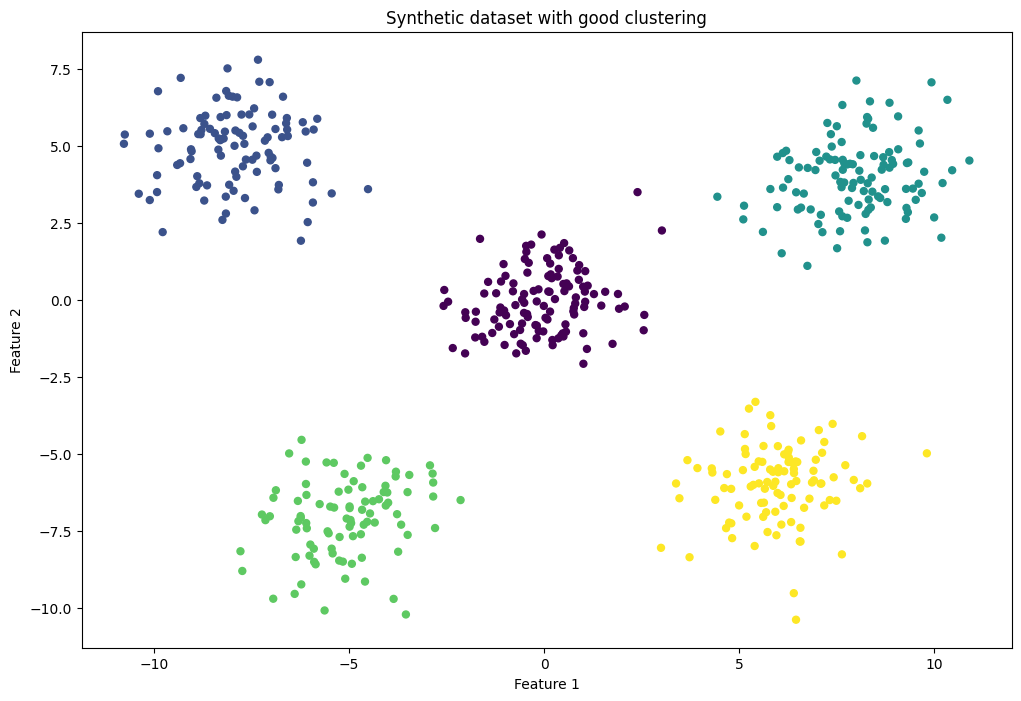

In [4]:
plot_synthetic_points(X, y, "Synthetic dataset with good clustering")

#### Real-world datasets

The MNIST dataset is a widely used benchmark in machine learning, consisting of $70000$ grayscale images of handwritten digits $(0–9)$, each represented as a $784$-dimensional vector obtained by flattening $28$ $\times$ $28$ pixel images. 

From original dataset, i take a subset of $2000$ examples, due to computational matters.

In [5]:
X_mnist, y_mnist = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

subset_size = 2000
random_state_mnist = 42

X_mnist = X_mnist.astype(np.float64) / 255.0
y_mnist = y_mnist.astype(int)

rng = np.random.default_rng(random_state_mnist)
idx = rng.choice(X_mnist.shape[0], size=subset_size, replace=False)

X_mnist = X_mnist[idx]
y_mnist = y_mnist[idx]

print("Shape X_MNIST =", X_mnist.shape)
print("Shape y_MNIST =", y_mnist.shape)

df_mnist = pd.DataFrame(X_mnist)
df_mnist["label"] = y_mnist

df_mnist

Shape X_MNIST = (2000, 784)
Shape y_MNIST = (2000,)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [6]:
df_mnist['label'].value_counts()

label
7    230
4    218
1    216
0    207
3    205
8    198
9    196
2    187
6    182
5    161
Name: count, dtype: int64

#### Run K-Means and K-means++

Multiple runs of Kmeans and Kmeans++ on synthetic dataset with good clustering.

In [7]:
# settings
n_clusters = 5
n_runs = 50
max_iter = 100
tol = 1e-4

inertias_kmeans = []
n_iters_kmeans = []
labels_kmeans = []
centroids_kmeans = [] 

inertias_kmeanspp = []
n_iters_kmeanspp = []
labels_kmeanspp = []
centroids_kmeanspp = []

for seed in range(n_runs):
    # kmeans
    model_kmeans = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans.fit(X)

    inertias_kmeans.append(model_kmeans.inertia)
    n_iters_kmeans.append(model_kmeans.n_iter)
    labels_kmeans.append(model_kmeans.labels.copy())
    centroids_kmeans.append(model_kmeans.centroids.copy())

    # kmeans++
    model_kmeanspp = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp.fit(X)

    inertias_kmeanspp.append(model_kmeanspp.inertia)
    n_iters_kmeanspp.append(model_kmeanspp.n_iter)
    labels_kmeanspp.append(model_kmeanspp.labels.copy())
    centroids_kmeanspp.append(model_kmeanspp.centroids.copy())

inertias_kmeans = np.array(inertias_kmeans)
n_iters_kmeans = np.array(n_iters_kmeans)

inertias_kmeanspp = np.array(inertias_kmeanspp)
n_iters_kmeanspp = np.array(n_iters_kmeanspp)

Multiple runs of Kmeans and Kmeans++ on MNIST dataset.

In [8]:
# settings
n_clusters = 10
n_runs = 50
max_iter = 100
tol = 1e-4

inertias_kmeans_mnist = []
n_iters_kmeans_mnist = []
labels_kmeans_mnist = []
centroids_kmeans_mnist = [] 

inertias_kmeanspp_mnist = []
n_iters_kmeanspp_mnist = []
labels_kmeanspp_mnist = []
centroids_kmeanspp_mnist = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_mnist = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_mnist.fit(X_mnist)

    inertias_kmeans_mnist.append(model_kmeans_mnist.inertia)
    n_iters_kmeans_mnist.append(model_kmeans_mnist.n_iter)
    labels_kmeans_mnist.append(model_kmeans_mnist.labels.copy())
    centroids_kmeans_mnist.append(model_kmeans_mnist.centroids.copy())

    # kmeans++
    model_kmeanspp_mnist = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp_mnist.fit(X_mnist)

    inertias_kmeanspp_mnist.append(model_kmeanspp_mnist.inertia)
    n_iters_kmeanspp_mnist.append(model_kmeanspp_mnist.n_iter)
    labels_kmeanspp_mnist.append(model_kmeanspp_mnist.labels.copy())
    centroids_kmeanspp_mnist.append(model_kmeanspp_mnist.centroids.copy())

inertias_kmeans_mnist = np.array(inertias_kmeans_mnist)
n_iters_kmeans_mnist = np.array(n_iters_kmeans_mnist)

inertias_kmeanspp_mnist = np.array(inertias_kmeanspp_mnist)
n_iters_kmeanspp_mnist = np.array(n_iters_kmeanspp_mnist)

#### Results K-Means and K-means++ on synthetic dataset (well-separated)

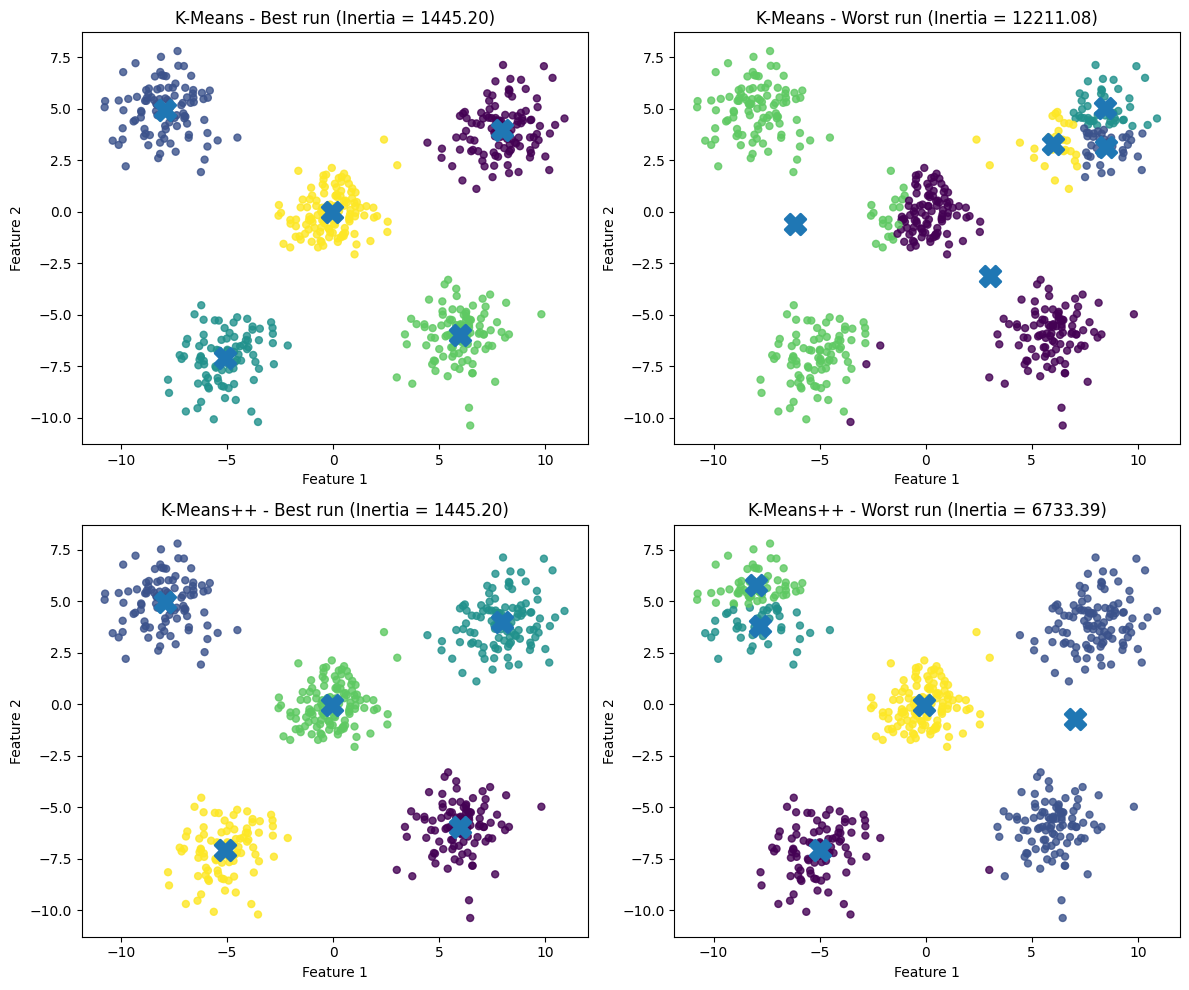

In [9]:
plot_best_worst_comparison(
    X,
    inertias_kmeans,
    labels_kmeans,
    centroids_kmeans,
    inertias_kmeanspp,
    labels_kmeanspp,
    centroids_kmeanspp
)

In [10]:
results_kmeans_kmeanspp(X,
                        inertias_kmeans,
                        n_iters_kmeans,
                        inertias_kmeanspp,
                        n_iters_kmeanspp)


K-Means
--------
Mean inertia    : 3846.6721
Std inertia     : 3114.8178
Min inertia     : 1445.1999
Max inertia     : 12211.0824
Mean iterations : 7.24

K-Means++
-----------
Mean inertia    : 1775.2924
Std inertia     : 1135.4003
Min inertia     : 1445.1999
Max inertia     : 6733.3857
Mean iterations : 3.88


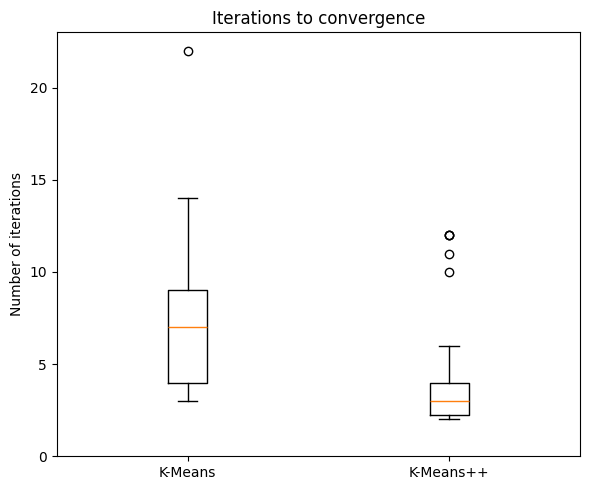

In [11]:
plot_iterations(n_iters_kmeans, n_iters_kmeanspp)

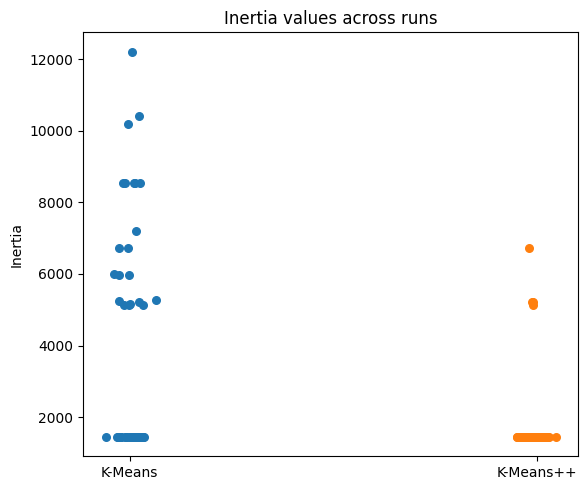

In [12]:
plot_strip(inertias_kmeans, inertias_kmeanspp)

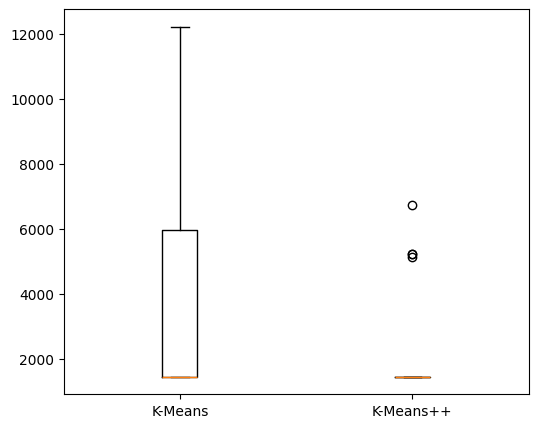

In [13]:
boxplot(inertias_kmeans, inertias_kmeanspp)

#### Results K-Means and K-means++ on MNIST dataset    

In [14]:
results_kmeans_kmeanspp(X_mnist,
                        inertias_kmeans_mnist,
                        n_iters_kmeans_mnist,
                        inertias_kmeanspp_mnist,
                        n_iters_kmeanspp_mnist)


K-Means
--------
Mean inertia    : 78771.3477
Std inertia     : 257.8803
Min inertia     : 78369.3144
Max inertia     : 79754.5337
Mean iterations : 29.54

K-Means++
-----------
Mean inertia    : 78816.3558
Std inertia     : 288.7149
Min inertia     : 78376.6201
Max inertia     : 79565.6179
Mean iterations : 31.20


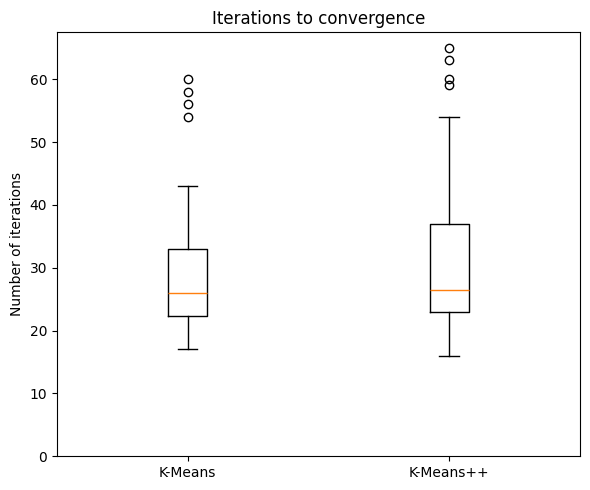

In [15]:
plot_iterations(n_iters_kmeans_mnist, n_iters_kmeanspp_mnist)

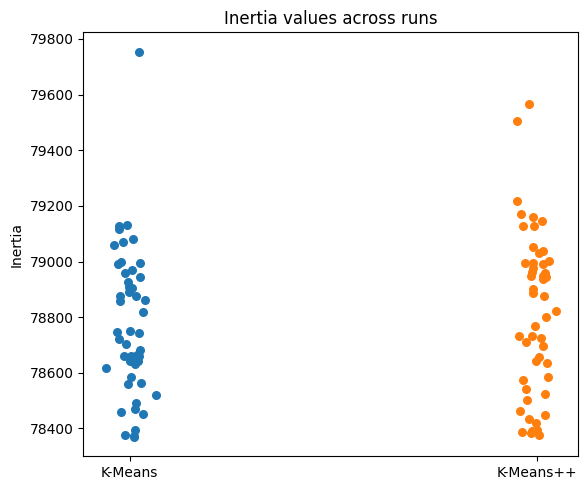

In [16]:
plot_strip(inertias_kmeans_mnist, inertias_kmeanspp_mnist)

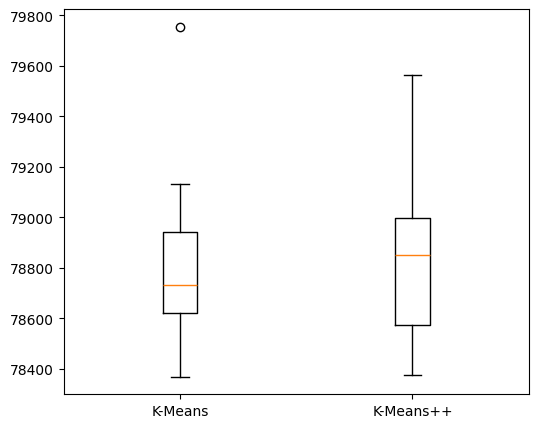

In [17]:
boxplot(inertias_kmeans_mnist, inertias_kmeanspp_mnist)

#### Overlapping clusters

In [18]:
centers_overlapping = [
    ( 0,  0),   
    (-8,  5),   
    ( 8,  4),   
    (-5, -7),   
    ( 6, -6)   
]

cluster_sizes = [120, 100, 110, 90, 100]

n_samples = 500     # total number of points 
std = 5             # deviation standard
n_features = 2      # number of features
random_state = 42   # random seed

X_overlapping, y_overlapping = generate_blobs(centers=centers_overlapping, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

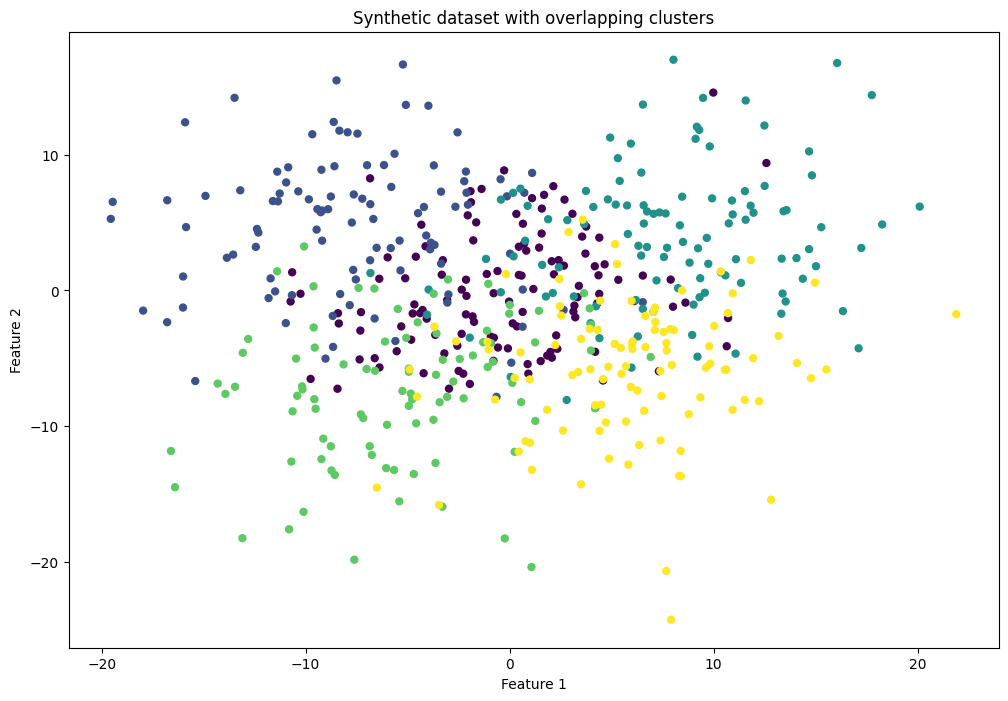

In [19]:
plot_synthetic_points(X_overlapping, y_overlapping, "Synthetic dataset with overlapping clusters")

In [20]:
# settings
n_clusters = 5
n_runs = 50
max_iter = 100
tol = 1e-4

inertias_kmeans_overlapping = []
n_iters_kmeans_overlapping = []
labels_kmeans_overlapping = []
centroids_kmeans_overlapping = [] 

inertias_kmeanspp_overlapping = []
n_iters_kmeanspp_overlapping = []
labels_kmeanspp_overlapping = []
centroids_kmeanspp_overlapping = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_overlapping = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_overlapping.fit(X_overlapping)

    inertias_kmeans_overlapping.append(model_kmeans_overlapping.inertia)
    n_iters_kmeans_overlapping.append(model_kmeans_overlapping.n_iter)
    labels_kmeans_overlapping.append(model_kmeans_overlapping.labels.copy())
    centroids_kmeans_overlapping.append(model_kmeans_overlapping.centroids.copy())

    # kmeans++
    model_kmeanspp_overlapping = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp_overlapping.fit(X_overlapping)

    inertias_kmeanspp_overlapping.append(model_kmeanspp_overlapping.inertia)
    n_iters_kmeanspp_overlapping.append(model_kmeanspp_overlapping.n_iter)
    labels_kmeanspp_overlapping.append(model_kmeanspp_overlapping.labels.copy())
    centroids_kmeanspp_overlapping.append(model_kmeanspp_overlapping.centroids.copy())

inertias_kmeans_overlapping = np.array(inertias_kmeans_overlapping)
n_iters_kmeans_overlapping = np.array(n_iters_kmeans_overlapping)

inertias_kmeanspp_overlapping = np.array(inertias_kmeanspp_overlapping)
n_iters_kmeanspp_overlapping = np.array(n_iters_kmeanspp_overlapping)

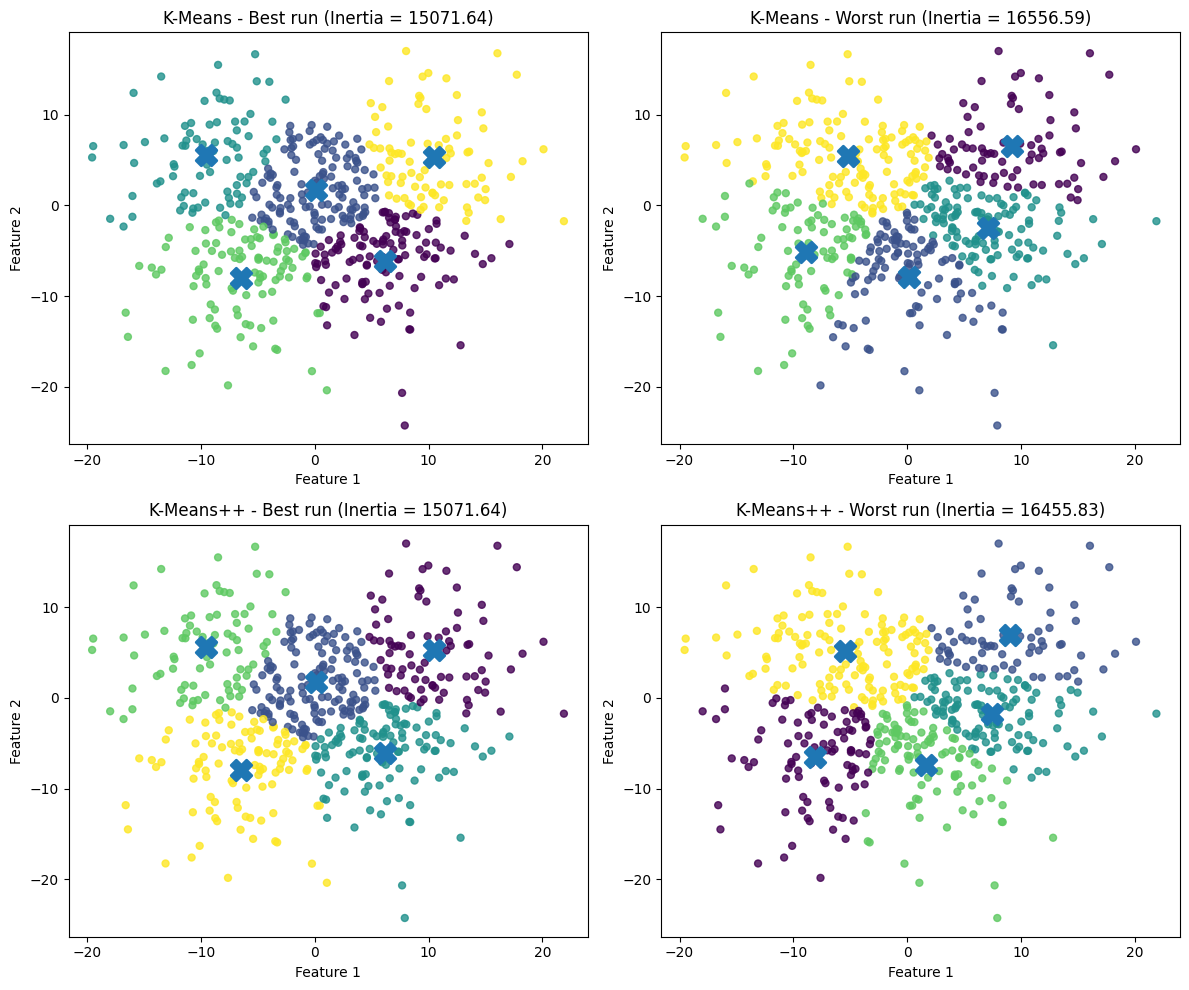

In [21]:
plot_best_worst_comparison(
    X_overlapping,
    inertias_kmeans_overlapping,
    labels_kmeans_overlapping,
    centroids_kmeans_overlapping,
    inertias_kmeanspp_overlapping,
    labels_kmeanspp_overlapping,
    centroids_kmeanspp_overlapping
)

In [22]:
results_kmeans_kmeanspp(X_overlapping,
                        inertias_kmeans_overlapping,
                        n_iters_kmeans_overlapping,
                        inertias_kmeanspp_overlapping,
                        n_iters_kmeanspp_overlapping)


K-Means
--------
Mean inertia    : 15447.1556
Std inertia     : 470.2300
Min inertia     : 15071.6371
Max inertia     : 16556.5887
Mean iterations : 16.72

K-Means++
-----------
Mean inertia    : 15296.7253
Std inertia     : 355.0358
Min inertia     : 15071.6371
Max inertia     : 16455.8327
Mean iterations : 19.84


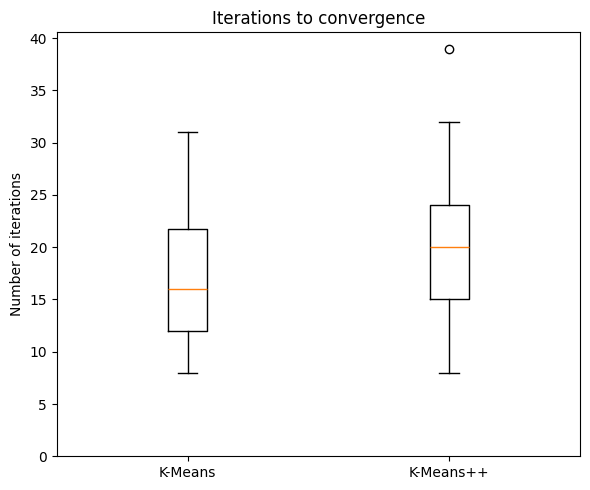

In [23]:
plot_iterations(n_iters_kmeans_overlapping, n_iters_kmeanspp_overlapping)

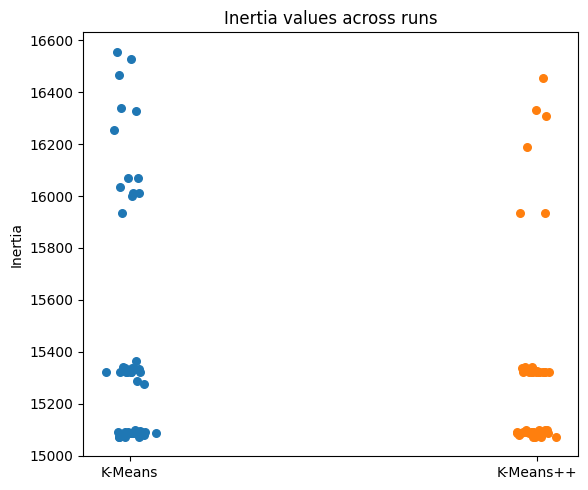

In [24]:
plot_strip(inertias_kmeans_overlapping, inertias_kmeanspp_overlapping)

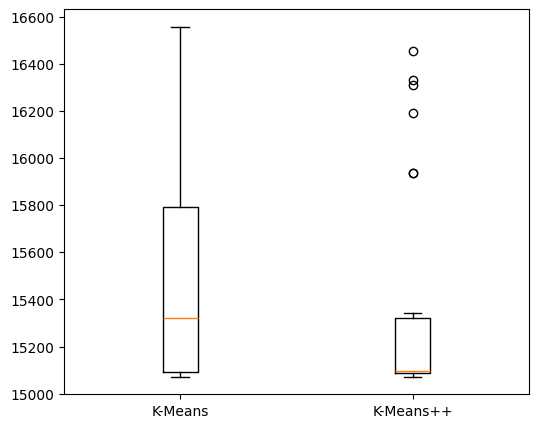

In [25]:
boxplot(inertias_kmeans_overlapping, inertias_kmeanspp_overlapping)